# Yellow Taxi — Model 1 & Model 2

Estimates from the identification ladder (see [`docs/burden_analysis_and_modeling_plan.md`](../docs/burden_analysis_and_modeling_plan.md)),
on the DS_z pipeline outputs (`data/processed/disruption_score/yellow_*.csv`).

- **Model 1** — cross-zone: is higher burden (`DS_z`) associated with bigger volume loss?
  (correlational — a first descriptive look at the burden–volume link.)
- **Model 2** — **CRZ exposure DiD**: do zone-sides with higher pre-policy CRZ exposure
  (2024 charged-share) show larger relative volume declines in 2025?

**Data.** Standardized yellow trips, **Feb–Jun of 2024 and 2025** (matched windows). Volume counts
are **non-Flex** trips; `DS_z` uses **2025 charged card/cash** trips (see the data audit).

*Inference, not prediction: we report coefficients + CIs, Pearson/Spearman, quartiles — no
train/test, no accuracy scores.*

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data" / "processed").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
DS = REPO_ROOT / "data" / "processed" / "disruption_score"
TAB = REPO_ROOT / "results" / "tables"
TAB.mkdir(parents=True, exist_ok=True)

# CRZ = 38 Congestion Relief Zone LocationIDs (Manhattan south of 60th St).
CRZ = {4,12,13,45,48,50,68,79,87,88,90,100,107,113,114,125,137,144,148,158,161,162,163,164,
       170,186,209,211,224,229,230,231,232,233,234,246,249,261}

def corr_ci(x, y, method="pearson"):
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y); x, y = x[ok], y[ok]; n = len(x)
    r = (stats.pearsonr if method == "pearson" else stats.spearmanr)(x, y)[0]
    z, se = np.arctanh(r), 1 / np.sqrt(n - 3)          # Fisher-z 95% CI
    return r, np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se), n

ds_vol = pd.read_csv(DS / "yellow_ds_z_vs_volume_change.csv")
shift  = pd.read_csv(DS / "yellow_behavioral_shift.csv")
print("DS_z↔volume rows:", len(ds_vol), "| behavioral_shift rows:", len(shift))


DS_z↔volume rows: 509 | behavioral_shift rows: 524


## Model 1 — DS_z ↔ volume change (cross-zone)

Stable zones only: `DS_z` on ≥100 charged trips **and** volume not low-N.

In [2]:
m1 = ds_vol[(ds_vol.N_z >= 100) & (~ds_vol.low_n_flag) & ds_vol.pct_volume_change.notna()].copy()
print(f"stable zone×direction units: {len(m1)}\n")
for meth in ["pearson", "spearman"]:
    r, lo, hi, n = corr_ci(m1.DS_z, m1.pct_volume_change, meth)
    print(f"DS_z ~ pct_volume_change  {meth:8s}: r = {r:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  (n={n})")

m1["dsz_quartile"] = pd.qcut(m1.DS_z, 4, labels=[1, 2, 3, 4])
print("\nQuartile breakdown (avg volume change by DS_z quartile):")
print(m1.groupby("dsz_quartile", observed=True)
        .agg(avg_DS_z=("DS_z", "mean"), avg_vol_change=("pct_volume_change", "mean"),
             n=("DS_z", "size")).round(4).to_string())

stable zone×direction units: 328

DS_z ~ pct_volume_change  pearson : r = -0.170  95% CI [-0.273, -0.063]  (n=328)
DS_z ~ pct_volume_change  spearman: r = -0.163  95% CI [-0.267, -0.056]  (n=328)

Quartile breakdown (avg volume change by DS_z quartile):
              avg_DS_z  avg_vol_change   n
dsz_quartile                              
1               0.0114          0.0377  82
2               0.0164          0.0559  83
3               0.0270          0.0427  81
4               0.0429         -0.0142  82


In [3]:
# Collinearity of the control with DS_z (2024 trip-length proxy).
r, lo, hi, n = corr_ci(m1.DS_z, m1.avg_distance_2024, "spearman")
print(f"DS_z ~ avg_distance_2024  spearman = {r:.3f}  CI [{lo:.3f}, {hi:.3f}]  "
      f"(pearson {m1.DS_z.corr(m1.avg_distance_2024):.3f})\n")

# The DS_z coefficient is NOT identified: at the zone level 'being charged the fee'
# (CRZ = Manhattan < 60th St), 'being a dense/short-trip zone', and 'high DS_z' are nearly
# the same object, so no control removes the dense-core confound without also removing the
# treatment. The coefficient swings with the spec — that instability IS the verdict.
specs = {
    "DS_z only (raw)"      : "pct_volume_change ~ DS_z",
    "+ borough only"       : "pct_volume_change ~ DS_z + C(Borough)",
    "+ distance only"      : "pct_volume_change ~ DS_z + avg_distance_2024",
    "+ distance + borough" : "pct_volume_change ~ DS_z + avg_distance_2024 + C(Borough)",
    "+ cost only"          : "pct_volume_change ~ DS_z + avg_total_cost_2024",
    "+ cost + borough"     : "pct_volume_change ~ DS_z + avg_total_cost_2024 + C(Borough)",
}
print(f"{'spec':<24}{'B(DS_z)':>9}{'  95% CI':>18}{'  SE':>8}")
for name, f in specs.items():
    mod = smf.ols(f, m1).fit(); b = mod.params["DS_z"]; ci = mod.conf_int().loc["DS_z"]
    print(f"{name:<24}{b:9.3f}   [{ci[0]:6.2f},{ci[1]:6.2f}]{mod.bse['DS_z']:8.3f}")

DS_z ~ avg_distance_2024  spearman = -0.900  CI [-0.919, -0.877]  (pearson -0.823)

spec                      B(DS_z)            95% CI      SE
DS_z only (raw)            -2.042   [ -3.33, -0.75]   0.655
+ borough only              0.949   [ -1.24,  3.13]   1.111
+ distance only            -5.114   [ -7.35, -2.88]   1.138
+ distance + borough       -3.610   [ -6.46, -0.76]   1.448
+ cost only                -3.614   [ -5.72, -1.51]   1.070
+ cost + borough           -1.348   [ -4.13,  1.43]   1.412


### Geographic diagnostic — does the Model 1 pattern remain within strata?

It asks whether the weak overall `DS_z`↔volume relationship remains visible after separating Manhattan, outer-borough, and airport zone-directions.


In [4]:
AIRPORT_ZONES = {132, 138}   # JFK and LaGuardia; Newark/EWR kept separate.
m1_geo = m1.copy()
m1_geo['zone_type'] = np.select(
    [m1_geo.zone.isin(AIRPORT_ZONES), m1_geo.Borough.eq('EWR'), m1_geo.Borough.eq('Manhattan')],
    ['airport', 'ewr', 'manhattan'], default='outer')

rows = []
for zt in ['(all)', 'manhattan', 'outer', 'airport', 'ewr']:
    sub = m1_geo if zt == '(all)' else m1_geo[m1_geo.zone_type.eq(zt)]
    row = {'stratum': zt, 'n': len(sub), 'median_DS_z': round(sub.DS_z.median(), 4)}
    if len(sub) < 5:
        row.update({'pearson_r': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'note': 'n too small'})
    else:
        r, lo, hi, n = corr_ci(sub.DS_z, sub.pct_volume_change, 'pearson')
        row.update({'pearson_r': round(r, 3), 'ci_low': round(lo, 3), 'ci_high': round(hi, 3), 'note': ''})
    rows.append(row)
geo_diag = pd.DataFrame(rows)
geo_diag.to_csv(TAB / 'yellow_model1_burden_volume_by_stratum.csv', index=False)
print('DS_z <-> pct_volume_change by stratum:')
print(geo_diag.to_string(index=False))

man = m1_geo[m1_geo.zone_type.eq('manhattan')].copy()
man['q'] = pd.qcut(man.DS_z, 4, labels=[1, 2, 3, 4])
manq = (man.groupby(['direction', 'q'], observed=True)
        .agg(avg_DS_z=('DS_z', 'mean'), avg_vol=('pct_volume_change', 'mean'), n=('DS_z', 'size'))
        .reset_index())
manq.to_csv(TAB / 'yellow_model1_within_manhattan_quartiles.csv', index=False)
print('\nWithin-Manhattan DS_z quartiles (avg volume change):')
print(manq.round(4).to_string(index=False))


DS_z <-> pct_volume_change by stratum:
  stratum   n  median_DS_z  pearson_r  ci_low  ci_high        note
    (all) 328       0.0204     -0.170  -0.273   -0.063            
manhattan 126       0.0408      0.073  -0.103    0.245            
    outer 197       0.0150     -0.010  -0.150    0.130            
  airport   4       0.0108        NaN     NaN      NaN n too small
      ewr   1       0.0067        NaN     NaN      NaN n too small

Within-Manhattan DS_z quartiles (avg volume change):
direction q  avg_DS_z  avg_vol  n
  dropoff 1    0.0227  -0.0459 19
  dropoff 2    0.0363  -0.0046 17
  dropoff 3    0.0428  -0.0065 14
  dropoff 4    0.0457  -0.0040 16
   pickup 1    0.0249  -0.0073 13
   pickup 2    0.0363  -0.0077 14
   pickup 3    0.0426   0.0169 17
   pickup 4    0.0455  -0.0302 16


**Model 1 finding — a weak correlation that is *not identified* as a causal effect.**
The cross-zone `DS_z`↔volume association is **weak** (Pearson/Spearman ≈ −0.17, CI excludes 0): the top-burden quartile is the only one with a volume decline (Q1 +3.8% → Q4 −1.4%),
a shallow pattern.

This **cannot** be read as the fee's effect, because at the **zone level** three things are nearly
the same object: *being charged* (CRZ ≈ Manhattan south of 60th St), *being a dense / short-trip
zone*, and *high `DS_z`* (`DS_z` ≈ 1/base-cost; Pearson(`DS_z`, 2024 distance) ≈ −0.82). So no
control can remove the dense-core confound without also removing the treatment. The regression
makes the non-identification concrete — **the `DS_z` coefficient swings with the spec**: raw −2.04;
`+ borough` **+0.95** (flips sign, CI incl. 0); `+ distance` −5.11; `+ both` −3.61, with the CI
roughly doubling.

Controlling for borough flattens the coefficient not because it isolates a clean estimate but
because the fee is itself almost entirely a Manhattan phenomenon — "holding borough fixed" also
holds most of the treatment fixed. The geographic diagnostic tells the same story: within Manhattan the correlation is +0.07 (CI includes 0), and outer-borough zone-directions are near 0. So the flip is **not** evidence that "it's the confound, not the fee"; it is
evidence that Model 1 **cannot separate the two**.

Bottom line: Model 1 is only a first correlational look at whether burden lines up with volume change, and that volume effect is **unidentified** — not a known bias direction, an inability to attribute. That is why we move to the DiD designs: **Model 2** adds
a geographic control group + time dimension (assumption becomes *inspectable*), and **Model 3** varies
fee size within the same zone (yellow $0.75 vs HVFHV $1.50), reducing the geographic confound but relying on its own cross-vehicle assumptions.


## Model 2 — CRZ exposure DiD 

**Design.**
1. **Exposure, not a CRZ binary.** Treatment = `charged_share`: the **2024 (pre-policy)**, direction-specific share of a zone×direction's trips that touch the CRZ. A binary `zone∈CRZ` mislabels the many outer-zone trips that go *into* the CRZ (they *are* charged) as control — contaminating it; the continuous share avoids this.
2. **Monthly panel** (`zone×direction×month×year`, Feb–Jun × 2024/2025), so within-window seasonality / limited pre-window movement is inspectable.
3. **Cluster-by-zone SE** (repeated monthly rows of a zone are correlated).

**What the coefficient means.** `post × charged_share` compares higher-exposure zone-sides with lower-exposure zone-sides: did places whose trips more often touched the CRZ change more in 2025? It is not a trip-level "charged vs not" individual effect. Any *uniform* city-wide change is absorbed by `post`, so this model cannot estimate the total Yellow volume change attributable to the fee.
Model: `log_n ~ C(zone_dir) + C(month) + post + post:charged_share`.

**Exposure validation.** The 2024 geography-based `charged_share` is checked against the 2025 observed card/cash fee flag. Precision and recall are high; the recall gap is the one geographic limitation the design cannot remove — trips that only *pass through* the CRZ (neither pickup nor dropoff inside it) are charged but not seen by pickup/dropoff geography. These through-trips are reported, not modeled.

In [5]:
val = pd.read_csv(DS / "yellow_charged_geo_validation.csv").iloc[0]
missed_through = val["fn_charged_through_only"] / (val["tp"] + val["fn_charged_through_only"])
print("Geography-based charged_share vs 2025 observed card/cash fee flag:")
print(f"  agreement : {val['agreement']*100:5.1f}%")
print(f"  precision : {val['precision_']*100:5.1f}%   (geography-exposed that were actually charged)")
print(f"  recall    : {val['recall_']*100:5.1f}%   (charged trips the geography rule captured)")
print(f"  through-trips missed by geography: {missed_through*100:.1f}% of charged card/cash trips")

Geography-based charged_share vs 2025 observed card/cash fee flag:
  agreement :  96.2%
  precision :  98.8%   (geography-exposed that were actually charged)
  recall    :  96.1%   (charged trips the geography rule captured)
  through-trips missed by geography: 3.9% of charged card/cash trips


In [6]:
mp = pd.read_csv(DS / "yellow_monthly_panel.csv")
mp = mp[mp.charged_share.notna()].copy()
# balanced panel: keep zone×direction with all 10 month cells and min monthly volume >= 30 (log stable)
cc = mp.groupby(["zone", "direction"]).size()
mp = mp.set_index(["zone", "direction"]).loc[cc[cc == 10].index].reset_index()
mp = mp[mp.groupby(["zone", "direction"]).n_trips.transform("min") >= 30].copy()
mp["zone_dir"] = mp.zone.astype(str) + "_" + mp.direction
mp["post"]  = (mp.year == 2025).astype(int)
mp["log_n"] = np.log(mp.n_trips)
mp["crz_int"] = mp.crz_zone.astype(int)
print(f"balanced panel: {mp.zone_dir.nunique()} zone×direction × 10 months = {len(mp)} rows")

# even the non-CRZ 'control' zone-sides are materially exposed -> a binary CRZ/non-CRZ contrast
# has a contaminated control (motivates using continuous exposure).
ctrl_med = mp[~mp.crz_zone].drop_duplicates(["zone", "direction"]).charged_share.median()
print(f"median charged_share among non-CRZ 'control' zone-sides = {ctrl_med:.2f} (materially exposed)")

# Selection-on-outcome check: the balanced filter uses 2025 too, so a zone-side whose 2025 volume
# collapsed could be dropped -> would bias *against* finding a drop. Quantify how many:
_r = pd.read_csv(DS / "yellow_monthly_panel.csv"); _r = _r[_r.charged_share.notna()]
_q24 = _r[_r.year == 2024].groupby(["zone", "direction"]).n_trips.agg(["size", "min"])
_q24 = set(_q24[(_q24["size"] == 5) & (_q24["min"] >= 30)].index)     # would qualify on 2024 alone
_excl = _q24 - set(zip(mp.zone, mp.direction))
_r25 = _r[_r.year == 2025].assign(zd=list(zip(_r[_r.year == 2025].zone, _r[_r.year == 2025].direction)))
_m25 = _r25[_r25.zd.isin(_excl)].groupby("zd").n_trips.min()
print(f"qualify on 2024 alone: {len(_q24)}; excluded only by the 2025 filter: {len(_excl)} "
      f"— all near the cutoff (2025 min-month {int(_m25.min())}–{int(_m25.max())} vs the 30 threshold), "
      f"negligible selection-on-outcome risk")

balanced panel: 455 zone×direction × 10 months = 4550 rows
median charged_share among non-CRZ 'control' zone-sides = 0.21 (materially exposed)
qualify on 2024 alone: 464; excluded only by the 2025 filter: 9 — all near the cutoff (2025 min-month 24–29 vs the 30 threshold), negligible selection-on-outcome risk


### Population robustness — why the panel excludes Flex

The panel counts **non-Flex** trips. Flex Fare (upfront-priced, `payment_type 0`) is a separately-priced regime whose pilot→permanent launch (effective **2024-09-21**) lands *between* the two windows, so its 2024→2025 jump is a program change, not the fee. Counting it would fabricate a spurious volume rise: the raw all-yellow total climbs while the fee-relevant non-Flex population is flat. (See `docs/yellow_data_audit.md` §6.)

In [7]:
# Contrast the raw Feb–Jun 2024→2025 volume change across populations (single-threaded = reproducible).
import duckdb
_con = duckdb.connect(); _con.execute("SET threads TO 1")
_g = (REPO_ROOT / "data/processed/00_standardized_trips/yellow").as_posix() + "/*/*.parquet"
_pop = _con.execute(f"""
    SELECT year,
      COUNT(*)                                            AS all_yellow,
      SUM(CASE WHEN NOT flex_fare_flag THEN 1 ELSE 0 END) AS non_flex,
      SUM(CASE WHEN flex_fare_flag     THEN 1 ELSE 0 END) AS flex
    FROM read_parquet('{_g}')
    WHERE year IN (2024, 2025) AND month BETWEEN 2 AND 6
      AND NOT (zero_distance_flag AND (PULocationID = DOLocationID OR trip_duration_seconds < 60))
    GROUP BY year ORDER BY year
""").df().set_index("year")
_chg = lambda c: (_pop.loc[2025, c] / _pop.loc[2024, c] - 1) * 100
_sh  = lambda y: _pop.loc[y, "flex"] / _pop.loc[y, "all_yellow"] * 100
print("Feb–Jun 2024→2025 volume change by population:")
print(f"  all-yellow (incl. Flex) : {_chg('all_yellow'):+6.1f}%   <- what raw totals show")
print(f"  non-Flex  (M2 population): {_chg('non_flex'):+6.1f}%   <- flat")
print(f"  Flex only               : {_chg('flex'):+6.1f}%")
print(f"Flex share of yellow: {_sh(2024):.1f}% (2024) -> {_sh(2025):.1f}% (2025)")
print("=> the raw all-yellow rise is entirely Flex adoption; the fee-relevant non-Flex population is",
      "flat. Including Flex would confound the volume outcome, so the panel excludes it.")

Feb–Jun 2024→2025 volume change by population:
  all-yellow (incl. Flex) :  +16.9%   <- what raw totals show
  non-Flex  (M2 population):   -0.8%   <- flat
  Flex only               : +164.1%
Flex share of yellow: 10.7% (2024) -> 24.3% (2025)
=> the raw all-yellow rise is entirely Flex adoption; the fee-relevant non-Flex population is flat. Including Flex would confound the volume outcome, so the panel excludes it.


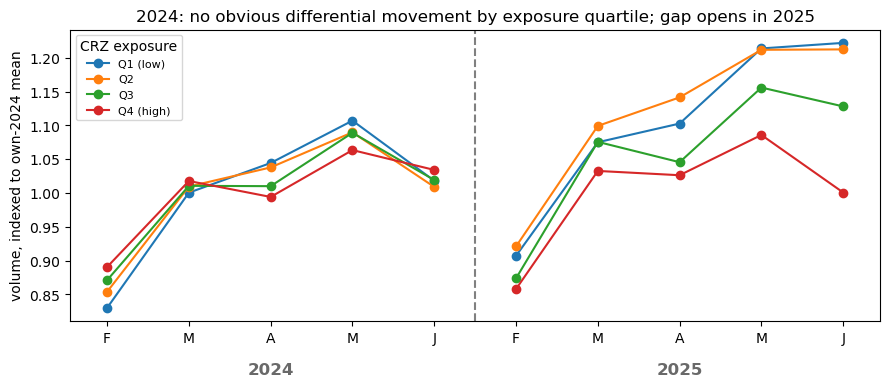

In [8]:
# Pre-trend: index each zone×direction to its own 2024 mean, average by 2024-exposure quartile.
# NB: indexing to each unit's own 2024 mean mechanically pins the 2024 level ~1, so this is a
# weak seasonality check (no obvious differential movement), NOT a full parallel-trends test.
base = mp[mp.year == 2024].groupby("zone_dir").n_trips.mean().rename("b24")
mp = mp.merge(base, on="zone_dir"); mp["idx"] = mp.n_trips / mp.b24
q = mp.drop_duplicates("zone_dir")[["zone_dir", "charged_share"]].copy()
q["exp_q"] = pd.qcut(q.charged_share, 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
mp = mp.merge(q[["zone_dir", "exp_q"]], on="zone_dir")

import matplotlib.pyplot as plt
traj = mp.groupby(["exp_q", "year", "month"], observed=True).idx.mean().reset_index()
traj["t"] = (traj.year - 2024) * 5 + (traj.month - 2)                 # 0..9 time axis
fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10.colors
for i, (name, g) in enumerate(traj.groupby("exp_q", observed=True)):
    g = g.sort_values("t")
    for yr in (2024, 2025):                                    # break the line across the year gap
        gy = g[g.year == yr]
        ax.plot(gy.t, gy.idx, marker="o", color=colors[i],
                label=str(name) if yr == 2024 else None)
ax.axvline(4.5, ls="--", c="grey")
for xc, yr in [(2, "2024"), (7, "2025")]:                       # label each half clearly
    ax.text(xc, -0.14, yr, ha="center", va="top", transform=ax.get_xaxis_transform(),
            fontsize=12, weight="bold", color="dimgrey")
ax.set_xticks(range(10)); ax.set_xticklabels(list("FMAMJ") * 2)
ax.set_xlabel(""); ax.set_ylabel("volume, indexed to own-2024 mean")
ax.set_title("2024: no obvious differential movement by exposure quartile; gap opens in 2025")
ax.legend(title="CRZ exposure", fontsize=8); plt.tight_layout(); plt.show()

### Primary DiD — higher-exposure vs lower-exposure comparison

`post × charged_share` asks whether higher-exposure zone-sides changed more than lower-exposure zone-sides after the policy. Reported **equal-weighted** (each zone-side one vote) and **volume-weighted** (roughly each trip one vote), because the weighting changes what comparison the estimate represents. The binary CRZ contrast is a contamination diagnostic: its non-CRZ control is itself materially exposed.

In [9]:
def did(df, term, wls=False, exp="b24"):
    f = f"log_n ~ C(zone_dir) + C(month) + post + post:{term}"
    m = (smf.wls(f, df, weights=df[exp]) if wls else smf.ols(f, df)).fit(
        cov_type="cluster", cov_kwds={"groups": df.zone})
    b = m.params[f"post:{term}"]; lo, hi = m.conf_int().loc[f"post:{term}"]
    return (np.exp(b)-1)*100, (np.exp(lo)-1)*100, (np.exp(hi)-1)*100

for lbl, wls in [("higher-exposure, equal-weight ", False), ("higher-exposure, volume-weight", True)]:
    r = did(mp, "charged_share", wls)
    print(f"{lbl}: {r[0]:+.1f}%  [{r[1]:+.1f},{r[2]:+.1f}]" + ("   (trip-weighted view; CI incl. 0)" if wls else ""))
r = did(mp, "crz_int")
print(f"binary CRZ (contaminated ctrl): {r[0]:+.1f}%  [{r[1]:+.1f},{r[2]:+.1f}]")
print("=> equal-weighted estimate clearly negative, but volume-weighted estimate ~0 -> a per-zone-side pattern, not a"
      " trip-weighted effect.")

higher-exposure, equal-weight : -11.1%  [-13.7,-8.4]


higher-exposure, volume-weight: +1.4%  [-2.2,+5.1]   (trip-weighted view; CI incl. 0)


binary CRZ (contaminated ctrl): -7.1%  [-9.0,-5.1]
=> equal-weighted estimate clearly negative, but volume-weighted estimate ~0 -> a per-zone-side pattern, not a trip-weighted effect.


## Primary Placebo — 2023→2024 (no fee)

There was **no CBD fee in 2023 or 2024**, so the same design on 2023→2024 should give an estimate close to 0 if this exposure-based comparison is isolating the fee. A negative estimate there means high-exposure zones were *already* losing relative volume before the fee. **June
is excluded** — Canadian-wildfire smoke depressed NYC traffic in June 2023.
(Panel: [`yellow_2023_placebo_monthly_panel.csv`](../data/processed/disruption_score/yellow_2023_placebo_monthly_panel.csv),
built by `build_yellow_2023_placebo_panel.py`; exposure uses the pre-placebo **2023** share, no leakage.)

In [10]:
pl = pd.read_csv(DS / "yellow_2023_placebo_monthly_panel.csv")
pl = pl[pl.charged_share_2023.notna() & (pl.month != 6)].copy()   # June excluded (2023 wildfire)

def _prep(d, expcol):
    cc = d.groupby(["zone", "direction"]).size()
    d = d.set_index(["zone", "direction"]).loc[cc[cc == d.month.nunique()*2].index].reset_index()
    d = d[d.groupby(["zone", "direction"]).n_trips.transform("min") >= 30].copy()
    d["zone_dir"] = d.zone.astype(str) + "_" + d.direction
    d["post"] = (d.year == d.year.max()).astype(int); d["log_n"] = np.log(d.n_trips)
    d["exp"] = d[expcol]
    d = d.merge(d[d.year == d.year.min()].groupby("zone_dir").n_trips.mean().rename("b24"), on="zone_dir")
    return d
def _pg(d, wls=False):
    f = "log_n ~ C(zone_dir) + C(month) + post + post:exp"
    m = (smf.wls(f, d, weights=d.b24) if wls else smf.ols(f, d)).fit(cov_type="cluster", cov_kwds={"groups": d.zone})
    b = m.params["post:exp"]; lo, hi = m.conf_int().loc["post:exp"]
    return (np.exp(b)-1)*100, (np.exp(lo)-1)*100, (np.exp(hi)-1)*100

Ep = _prep(pl, "charged_share_2023")
print("M2 placebo 2023->2024 (NO fee; June excluded; 2023 no-leakage exposure). Should be ~0:")
print(f"  higher-exposure, equal-weight : {_pg(Ep)[0]:+.1f}%  [{_pg(Ep)[1]:+.1f},{_pg(Ep)[2]:+.1f}]")
print(f"  higher-exposure, volume-weight: {_pg(Ep, True)[0]:+.1f}%  [{_pg(Ep, True)[1]:+.1f},{_pg(Ep, True)[2]:+.1f}]")
man = _prep(pl[pl.Borough == "Manhattan"], "charged_share_2023")
print(f"  within-Manhattan   : {_pg(man)[0]:+.1f}%  [{_pg(man)[1]:+.1f},{_pg(man)[2]:+.1f}]")
print("\n  Real 2024->2025: equal-weight clearly negative, volume-weight ~0, within-Man ~0 (matching).")
print("  => equal-weighted estimate is large and negative with NO fee -> high-exposure zones")
print("     were already declining relative to low-exposure zones. WLS and within-Manhattan are ~0,")
print("     matching the real analysis and weakening a clean causal interpretation.")

M2 placebo 2023->2024 (NO fee; June excluded; 2023 no-leakage exposure). Should be ~0:


  higher-exposure, equal-weight : -25.8%  [-30.7,-20.4]


  higher-exposure, volume-weight: +5.5%  [-6.4,+19.0]
  within-Manhattan   : -1.2%  [-6.4,+4.3]

  Real 2024->2025: equal-weight clearly negative, volume-weight ~0, within-Man ~0 (matching).
  => equal-weighted estimate is large and negative with NO fee -> high-exposure zones
     were already declining relative to low-exposure zones. WLS and within-Manhattan are ~0,
     matching the real analysis and weakening a clean causal interpretation.


**Placebo finding — Model 2 does not support a clean causal interpretation.** On the no-fee 2023→2024 window, the equal-weighted higher-exposure estimate is ≈ **−26%** (CI well below 0), larger in magnitude than the 2024→2025 estimate of −11.1%. High-exposure zone-sides were already losing relative volume before the fee, so the 2024→2025 equal-weighted estimate cannot be cleanly attributed to the policy. The same two qualifications recur: volume-weighting moves the estimate close to 0, and within-Manhattan it is close to 0. The placebo reinforces the caution already implied by the WLS and within-Manhattan checks — the equal-weighted estimate is best read as a fragile geographic association.

## Additional diagnostic — within-Manhattan (within-core)

Restricting to Manhattan holds "dense core" roughly fixed. A negative estimate within Manhattan would be less exposed to the Manhattan-vs-outer-borough contrast; an estimate close to 0 is inconclusive, because the fee is almost entirely a Manhattan phenomenon and the Upper-Manhattan comparison group is itself partly exposed.

In [11]:
for name, term in [("within-Manhattan (binary CRZ)", "crz_int"),
                   ("within-Manhattan (exposure)", "charged_share")]:
    r = did(mp[mp.Borough == "Manhattan"], term)
    print(f"{name:<30}: {r[0]:+.1f}%  [{r[1]:+.1f},{r[2]:+.1f}]  (CI incl. 0)")
print("=> both ~0 -> inconclusive: a still-geographic contrast with a partly exposed comparison group,"
      " neither confirming nor refuting a fee interpretation.")

within-Manhattan (binary CRZ) : +1.7%  [-0.8,+4.2]  (CI incl. 0)
within-Manhattan (exposure)   : +1.6%  [-2.1,+5.5]  (CI incl. 0)
=> both ~0 -> inconclusive: a still-geographic contrast with a partly exposed comparison group, neither confirming nor refuting a fee interpretation.


## Robustness check — thin-unit trim

Trim low-volume zone-sides; only cutoffs dropping **≤10%** of units are meaningful (extreme cutoffs
collapse the panel to a mostly-Manhattan, high-exposure subsample where the exposure comparison is no longer well identified). Weighting (equal vs volume) is reported with the primary estimate above, since it changes what comparison the estimate represents.

In [12]:
def _grad(min_n):
    d = pd.read_csv(DS / "yellow_monthly_panel.csv"); d = d[d.charged_share.notna()].copy()
    cc = d.groupby(["zone", "direction"]).size()
    d = d.set_index(["zone", "direction"]).loc[cc[cc == 10].index].reset_index()
    d = d[d.groupby(["zone", "direction"]).n_trips.transform("min") >= min_n].copy()
    d["zone_dir"] = d.zone.astype(str) + "_" + d.direction
    d["post"] = (d.year == 2025).astype(int); d["log_n"] = np.log(d.n_trips)
    m = smf.ols("log_n ~ C(zone_dir) + C(month) + post + post:charged_share", d).fit(
        cov_type="cluster", cov_kwds={"groups": d.zone})
    return d.zone_dir.nunique(), (np.exp(m.params["post:charged_share"]) - 1) * 100

base = _grad(30)[0]
print("thin-unit trim (equal-weight; cutoffs dropping <=10% of units):")
print(f"{'min_n':>6}{'units':>7}{'dropped':>9}{'estimate':>10}")
for mn in [30, 40, 50, 60, 75]:
    u, g = _grad(mn); print(f"{mn:>6}{u:>7}{1-u/base:>9.1%}{g:>+9.1f}%")
print("=> equal-weighted estimate is stable to non-distorting trims: not driven by a few thin units.")

thin-unit trim (equal-weight; cutoffs dropping <=10% of units):
 min_n  units  dropped  estimate


    30    455     0.0%    -11.1%


    40    444     2.4%    -10.5%


    50    438     3.7%    -10.5%


    60    424     6.8%    -10.7%


    75    415     8.8%    -10.5%
=> equal-weighted estimate is stable to non-distorting trims: not driven by a few thin units.


**Model 2 finding — a fragile geographic association, not clean causal evidence.**

- **The equal-weighted higher-exposure estimate is ≈ −11.1%** (CI excludes 0), stable to non-distorting trims — a statistically clear per-zone-side pattern.
- **But it should not be read as a clean fee effect.** (i) **Weighting** moves the estimate to +1.4% with a CI including 0 — the negative result is an equal-weighted, per-zone-side pattern rather than a trip-weighted pattern; (ii) **within-Manhattan** it is ≈ 0 (inconclusive — still geographic, with a partly exposed comparison group); (iii) **the 2023→2024 placebo is strongly negative** — the same design gives an even larger negative estimate (≈ −26%) with no fee present, so high-exposure zones were already losing relative volume before the policy.
- **Read the −11.1% as a fragile geographic association, not clean causal evidence of the fee.** The volume-weighted estimate is close to zero with a CI including 0; the placebo shows that the equal-weighted high-vs-low exposure pattern existed before the policy window.

## Summary
- **Model 1** (cross-zone `DS_z`↔volume): weak (≈ −0.17) and **not identified** — at the zone level
  "charged", "dense", and "high `DS_z`" are nearly the same object, so the coefficient swings with the
  spec. It is a descriptive burden–volume association, not an identified volume effect.
- **Model 2** (CRZ exposure DiD): an equal-weighted −11.1% estimate for higher-exposure zone-sides, but it is not stable across the checks needed for causal interpretation — volume-weighting moves it close to 0, within-Manhattan is close to 0, and the **2023→2024 placebo** is strongly negative (≈ −26% with no fee). A fragile geographic association, not clean evidence of a fee effect.
- **Net for yellow:** the current evidence does not establish a robust Yellow-only volume reduction attributable to the fee. 